# 01 — Single-Omics Baseline (Gene Expression)

**Purpose:** the single-omics baseline for the 3-way comparison — Elastic-Net Cox and Random Survival Forest trained on gene expression alone, evaluated on the **fixed reference cohort and CV folds** from `00_build_reference_cohort.ipynb`.

This uses `common_utils.py` for all modeling logic, so the exact same fitting/evaluation code is reused identically by `02_model_concatenated.ipynb` and `03_model_mofa.ipynb` — the only thing that differs between experiments is the input feature matrix.

**Before running:** make sure `common_utils.py` is in the same folder as this notebook, and that `reference_cohort/` (from notebook `00`) and `expression_filtered.csv` are both present.

**Workflow:**
1. Run with `DEBUG_MODE = True` first — should finish in well under a minute, and catches any plumbing errors before committing to the full run
2. Once it runs clean, flip to `DEBUG_MODE = False` and re-run for the real result


## 1. Imports

In [1]:
import common_utils as cu
import numpy as np


## 2. Configuration

Flip `debug_mode` here. Everything else in this notebook reads its settings from `cu.CONFIG`, so this is the only switch you need.

In [2]:
cu.CONFIG["debug_mode"] = True   # <-- flip to False for the real, full-scale run

cu.CONFIG["reference_cohort_dir"] = "reference_cohort"
EXPRESSION_FILE = "expression_filtered.csv"

EXPERIMENT_NAME = "expression"


## 3. Load data

Restricted automatically to the fixed reference cohort + folds from notebook `00`.

In [3]:
X, y, fold_arr, samples, feature_names = cu.load_reference_cohort(feature_file=EXPRESSION_FILE)


Loaded 60 samples x 200 features, 5 folds.
  (DEBUG_MODE: subsetting to top 200 variance features)


## 4. Run cross-validation

Elastic-Net Cox and Random Survival Forest, evaluated out-of-fold on the fixed CV splits.

In [4]:
results = cu.run_cross_validation(X, y, fold_arr)


[fold 0] coxnet   C-index=0.500  IBS=0.259  (alpha=0.09921)
[fold 0] rsf      C-index=0.760  IBS=0.228


[fold 1] coxnet   C-index=0.500  IBS=0.181  (alpha=0.4346)
[fold 1] rsf      C-index=0.667  IBS=0.252


[fold 2] coxnet   C-index=0.500  IBS=0.330  (alpha=0.33)
[fold 2] rsf      C-index=0.597  IBS=0.307


[fold 3] coxnet   C-index=0.500  IBS=0.141  (alpha=0.3619)
[fold 3] rsf      C-index=0.750  IBS=0.134


[fold 4] coxnet   C-index=0.425  IBS=0.652  (alpha=0.005882)
[fold 4] rsf      C-index=0.521  IBS=0.208


## 5. Summary and comparison plot

In [5]:
cu.summarize_results(results)



=== Cross-validated performance (mean +/- std across folds) ===
coxnet    C-index = 0.485 +/- 0.030   IBS = 0.312 +/- 0.182
rsf       C-index = 0.659 +/- 0.091   IBS = 0.226 +/- 0.056


Saved model_comparison_expression.png


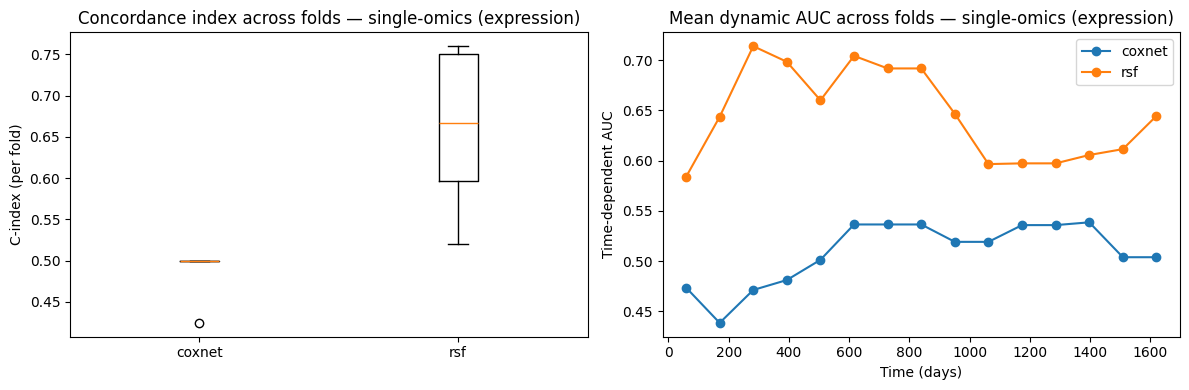

In [6]:
cu.plot_comparison(results, title_suffix=" — single-omics (expression)",
                    save_path=f"model_comparison_{EXPERIMENT_NAME}.png")


## 6. Feature importance

Refits both models on the full dataset (not per-fold) for a final, stable set of top features.

In [7]:
nonzero_coefs = cu.feature_importance_coxnet(X, y, feature_names, save_prefix=EXPERIMENT_NAME)


Elastic-Net Cox (full-data refit): alpha=0.3747, 0 nonzero features out of 200


RSF permutation importance computed on top 50 (by variance) of 200 total features.


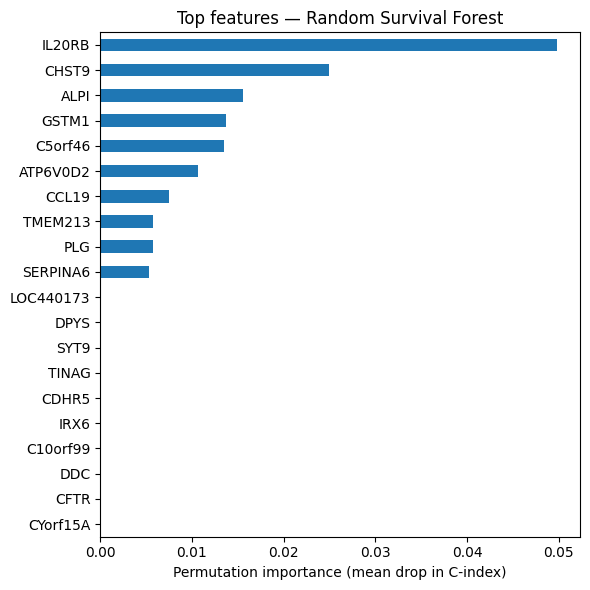

In [8]:
importances_rsf = cu.feature_importance_rsf(X, y, feature_names, save_prefix=EXPERIMENT_NAME)


## 7. Save results for the final 3-way comparison (notebook 04)

In [9]:
cu.save_results(EXPERIMENT_NAME, results)


Saved results to results/results_expression.pkl


## Summary

This experiment's results (`results_expression.pkl`) are now saved and ready for `04_compare_results.ipynb`, alongside `02_model_concatenated.ipynb` and `03_model_mofa.ipynb` once those are run on the same reference cohort.

**Reminder:** if you re-run this with `DEBUG_MODE = False` for the real result, expect it to take considerably longer (full 5000-gene feature set, full alpha grid, full RSF tree count) — consider running it via `tmux`/`screen` if on a shared server without a job scheduler, per the project plan.